In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
ratings = pd.read_csv(
    "../data/u.data",
    sep="\t",
    names=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp"
    ]
)

In [3]:
print(ratings.shape)
print(ratings.head())
print(ratings.info())

print("Users :", ratings.user_id.nunique())
print("Movies:", ratings.movie_id.nunique())

(100000, 4)
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None
Users : 943
Movies: 1682


In [4]:
ratings = ratings.sort_values(
    ["user_id", "timestamp"]
).reset_index(drop=True)

In [5]:
user_mapping = {
    u: i
    for i, u in enumerate(ratings.user_id.unique())
}

movie_mapping = {
    m: i + 1
    for i, m in enumerate(ratings.movie_id.unique())
}

ratings["user_id"] = ratings.user_id.map(user_mapping)
ratings["movie_id"] = ratings.movie_id.map(movie_mapping)

PAD_TOKEN = 0
NUM_USERS = ratings.user_id.nunique()
NUM_MOVIES = ratings.movie_id.nunique()
MASK_TOKEN = NUM_MOVIES + 1

In [6]:
user_sequences = (
    ratings
    .groupby("user_id")["movie_id"]
    .apply(list)
)

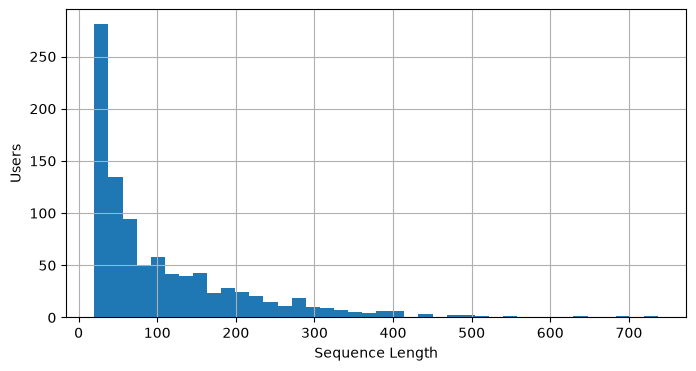

In [7]:
sequence_lengths = user_sequences.apply(len)

plt.figure(figsize=(8,4))

plt.hist(sequence_lengths, bins=40)

plt.xlabel("Sequence Length")
plt.ylabel("Users")
plt.grid(True)

plt.show()

In [8]:
MAX_LEN = 50

train_sequences = []
train_targets = []

test_sequences = []
test_targets = []

for sequence in user_sequences:

    if len(sequence) < 3:
        continue

    history = sequence[:-1]

    target = sequence[-1]

    train_sequences.append(
        history[-MAX_LEN:]
    )

    train_targets.append(
        target
    )

    test_sequences.append(
        history[-MAX_LEN:]
    )

    test_targets.append(
        target
    )

In [9]:
def left_pad(sequence, max_len):

    sequence = sequence[-max_len:]

    padding = [PAD_TOKEN] * (max_len - len(sequence))

    return padding + sequence

In [10]:
import random


def item_crop(sequence, crop_ratio=0.6):

    length = len(sequence)

    if length <= 1:
        return sequence.copy()

    crop_length = max(1, int(length * crop_ratio))

    if crop_length >= length:
        return sequence.copy()

    start = random.randint(0, length - crop_length)

    return sequence[start:start + crop_length]


def item_mask(sequence, mask_ratio=0.2):

    augmented = sequence.copy()

    length = len(augmented)

    num_mask = max(1, int(length * mask_ratio))

    indices = random.sample(range(length), num_mask)

    for idx in indices:
        augmented[idx] = PAD_TOKEN

    return augmented


def item_reorder(sequence, reorder_ratio=0.2):

    augmented = sequence.copy()

    length = len(augmented)

    if length <= 1:
        return augmented

    reorder_length = max(2, int(length * reorder_ratio))
    reorder_length = min(reorder_length, length)

    start = random.randint(0, length - reorder_length)

    subsequence = augmented[start:start + reorder_length]

    random.shuffle(subsequence)

    augmented[start:start + reorder_length] = subsequence

    return augmented


def augment(sequence):

    augmentation = random.choice(

        [

            item_crop,

            item_mask,

            item_reorder

        ]

    )

    return augmentation(sequence)

In [11]:
class CL4SRecDataset(Dataset):

    def __init__(
        self,
        sequences,
        targets,
        max_len,
    ):

        self.sequences = sequences          # Original sequences (list or numpy array)
        self.targets = targets              # Next-item targets
        self.max_len = max_len

    def __len__(self):

        return len(self.sequences)

    def __getitem__(self, idx):

        # -------------------------------------------------
        # Original sequence
        # -------------------------------------------------
        original = self.sequences[idx].copy()

        # -------------------------------------------------
        # Generate two independent augmented views
        # -------------------------------------------------
        view1 = augment(original.copy())
        view2 = augment(original.copy())

        # -------------------------------------------------
        # Left-pad every sequence back to MAX_LEN
        # -------------------------------------------------
        original = left_pad(original, self.max_len)
        view1 = left_pad(view1, self.max_len)
        view2 = left_pad(view2, self.max_len)

        # -------------------------------------------------
        # Target item
        # -------------------------------------------------
        target = self.targets[idx]

        # -------------------------------------------------
        # Return tensors
        # -------------------------------------------------
        return (

            torch.LongTensor(original),

            torch.LongTensor(view1),

            torch.LongTensor(view2),

            torch.tensor(target, dtype=torch.long)

        )

In [12]:
train_dataset = CL4SRecDataset(
    train_sequences,
    train_targets,
    MAX_LEN
)

test_dataset = CL4SRecDataset(
    test_sequences,
    test_targets,
    MAX_LEN
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

In [13]:
class TransformerBlock(nn.Module):
    """
    A single Transformer encoder block (post-LN variant used by SASRec).

    Architecture:

        x ──► Multi-Head Self-Attention ──► Dropout ──┐
        │                                            ├─► Add & LayerNorm
        └────────────────────────────────────────────┘
                              │
                              ▼
        x ──► Feed Forward Network ──► Dropout ──────┐
        │                                            ├─► Add & LayerNorm
        └────────────────────────────────────────────┘
    """

    def __init__(

        self,

        embedding_dim,

        num_heads,

        dropout,

    ):

        super().__init__()

        assert embedding_dim % num_heads == 0


        self.embedding_dim = embedding_dim

        self.num_heads = num_heads

        self.head_dim = embedding_dim // num_heads


        # -----------------------------
        # Query
        # -----------------------------

        self.query = nn.Linear(

            embedding_dim,

            embedding_dim

        )


        # -----------------------------
        # Key
        # -----------------------------

        self.key = nn.Linear(

            embedding_dim,

            embedding_dim

        )


        # -----------------------------
        # Value
        # -----------------------------

        self.value = nn.Linear(

            embedding_dim,

            embedding_dim

        )

        # -----------------------------
        # Output Projection
        # -----------------------------

        self.output = nn.Linear(

            embedding_dim,

            embedding_dim

        )

        # -----------------------------
        # Feed Forward Network
        # -----------------------------

        self.feed_forward = nn.Sequential(

            nn.Linear(

                embedding_dim,

                embedding_dim * 4

            ),

            nn.ReLU(),

            nn.Linear(

                embedding_dim * 4,

                embedding_dim

            )

        )

        # -----------------------------
        # Layer Normalization
        # -----------------------------

        self.layernorm1 = nn.LayerNorm(

            embedding_dim

        )

        self.layernorm2 = nn.LayerNorm(

            embedding_dim

        )

        # -----------------------------
        # Dropout
        # -----------------------------

        self.dropout = nn.Dropout(

            dropout

        )

    def forward(

        self,

        x,

        causal_mask,

        key_mask

    ):

        """
        x:           (batch, seq_len, embedding_dim)
        causal_mask: (1, 1, seq_len, seq_len) - True for future positions
        key_mask:    (batch, 1, 1, seq_len)  - True for padding key positions
        """

        batch_size, seq_len, _ = x.size()


        # -----------------------------
        # Q, K, V projections
        # -----------------------------

        queries = self.query(

            x

        ).view(

            batch_size,

            seq_len,

            self.num_heads,

            self.head_dim

        ).transpose(

            1,

            2

        )

        keys = self.key(

            x

        ).view(

            batch_size,

            seq_len,

            self.num_heads,

            self.head_dim

        ).transpose(

            1,

            2

        )

        values = self.value(

            x

        ).view(

            batch_size,

            seq_len,

            self.num_heads,

            self.head_dim

        ).transpose(

            1,

            2

        )


        # -----------------------------
        # Scaled Dot-Product Attention
        # -----------------------------

        attention_scores = torch.matmul(

            queries,

            keys.transpose(-2, -1)

        )

        attention_scores = attention_scores / math.sqrt(

            self.head_dim

        )

        # -----------------------------
        # Combine causal + padding mask
        # -----------------------------

        combined_mask = causal_mask | key_mask


        attention_scores = attention_scores.masked_fill(

            combined_mask,

            float("-inf")

        )

        # -----------------------------
        # Softmax with NaN safety
        # -----------------------------
        # With LEFT padding, position 0 may be padding.
        # Causal mask + padding mask then fully masks position 0's row,
        # which would give softmax(-inf) = NaN. Replace NaN with 0 so the
        # attention output stays finite (padding queries contribute 0).

        attention_weights = F.softmax(

            attention_scores,

            dim=-1

        )

        attention_weights = torch.nan_to_num(

            attention_weights,

            nan=0.0

        )

        attention_weights = self.dropout(

            attention_weights

        )


        attention_output = torch.matmul(

            attention_weights,

            values

        )

        attention_output = attention_output.transpose(

            1,

            2

        ).contiguous().view(

            batch_size,

            seq_len,

            self.embedding_dim

        )


        # -----------------------------
        # Output projection + dropout
        # (paper order: project, then dropout)
        # -----------------------------

        attention_output = self.dropout(

            self.output(

                attention_output

            )

        )

        # -----------------------------
        # Residual + LayerNorm
        # -----------------------------

        x = self.layernorm1(

            x + attention_output

        )


        # -----------------------------
        # Feed Forward + dropout
        # (paper order: FFN, then dropout)
        # -----------------------------

        ffn_output = self.dropout(

            self.feed_forward(

                x

            )

        )

        # -----------------------------
        # Residual + LayerNorm
        # -----------------------------

        x = self.layernorm2(

            x + ffn_output

        )


        return x


class SASRec(nn.Module):
    """
    Self-Attentive Sequential Recommendation (SASRec).

    Paper: Kang & McAuley, "Self-Attentive Sequential Recommendation",
           IEEE ICDM 2018.
    """

    def __init__(

        self,

        num_items,

        max_len,

        embedding_dim=64,

        num_heads=4,

        num_blocks=2,

        dropout=0.2

    ):

        super().__init__()

        assert embedding_dim % num_heads == 0


        self.max_len = max_len

        self.embedding_dim = embedding_dim

        self.num_heads = num_heads

        self.head_dim = embedding_dim // num_heads

        self.num_blocks = num_blocks


        # -----------------------------
        # Item Embedding
        # -----------------------------

        self.item_embedding = nn.Embedding(

            num_items + 1,

            embedding_dim,

            padding_idx=PAD_TOKEN

        )


        # -----------------------------
        # Position Embedding
        # -----------------------------

        self.position_embedding = nn.Embedding(

            max_len,

            embedding_dim

        )

        # -----------------------------
        # Stacked Transformer Blocks
        # -----------------------------

        self.blocks = nn.ModuleList(

            [

                TransformerBlock(

                    embedding_dim,

                    num_heads,

                    dropout

                )

                for _ in range(num_blocks)

            ]

        )

        # -----------------------------
        # Dropout (applied to input embeddings)
        # -----------------------------

        self.dropout = nn.Dropout(

            dropout

        )

        self._init_weights()


    def _init_weights(self):
        """
        Initialize weights following standard Transformer / SASRec conventions.

        - Linear layers: Xavier-uniform on weights, zeros on biases.
        - Embeddings:    Normal(0, 0.02), with padding_idx row zeroed out.
        """

        for module in self.modules():

            if isinstance(module, nn.Linear):

                nn.init.xavier_uniform_(

                    module.weight

                )

                if module.bias is not None:

                    nn.init.zeros_(

                        module.bias

                    )

            elif isinstance(module, nn.Embedding):

                nn.init.normal_(

                    module.weight,

                    mean=0.0,

                    std=0.02

                )

                if module.padding_idx is not None:

                    with torch.no_grad():

                        module.weight[

                            module.padding_idx

                        ].zero_()


    def forward(

        self,

        sequences

    ):

        """
        sequences: (batch, seq_len) - LongTensor of item ids (PAD_TOKEN = 0).
        Returns:   (batch, embedding_dim) - representation of the last real position.
        """

        batch_size, seq_len = sequences.size()


        # -----------------------------
        # Item + Position embeddings
        # -----------------------------

        item_embeddings = self.item_embedding(

            sequences

        )

        position_ids = torch.arange(

            seq_len,

            device=sequences.device

        ).unsqueeze(0).expand(

            batch_size,

            seq_len

        )

        position_embeddings = self.position_embedding(

            position_ids

        )

        x = self.dropout(

            item_embeddings + position_embeddings

        )


        # -----------------------------
        # Build masks
        # -----------------------------

        # Causal mask: shape (1, 1, seq_len, seq_len)
        # True at (i, j) where j > i (future positions).

        causal_mask = torch.triu(

            torch.ones(

                seq_len,

                seq_len,

                device=sequences.device,

                dtype=torch.bool

            ),

            diagonal=1

        ).unsqueeze(0).unsqueeze(0)


        # Padding mask: True for non-padding positions, shape (batch, seq_len).

        padding_mask = sequences != PAD_TOKEN


        # Key mask: True for padding positions (to mask as keys).
        # Shape (batch, 1, 1, seq_len) for broadcasting over heads and queries.

        key_mask = (~padding_mask).unsqueeze(1).unsqueeze(1)


        # -----------------------------
        # Pass through stacked transformer blocks
        # -----------------------------

        for block in self.blocks:

            x = block(

                x,

                causal_mask,

                key_mask

            )


        # -----------------------------
        # Last non-padding representation
        # -----------------------------

        lengths = padding_mask.sum(dim=1)

        representation = x[

            torch.arange(batch_size),

            lengths - 1

        ]


        return representation

In [14]:
class ProjectionHead(nn.Module):

    def __init__(self, embedding_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                embedding_dim,
                embedding_dim
            ),

            nn.BatchNorm1d(
                embedding_dim
            ),

            nn.ReLU(),

            nn.Linear(
                embedding_dim,
                embedding_dim
            )

        )

    def forward(self,x):

        return self.network(x)

In [15]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

model = SASRec(

    num_items=NUM_MOVIES + 1,

    max_len=MAX_LEN,

    embedding_dim=64,

    num_heads=4,

    num_blocks=2,

    dropout=0.2

).to(device)

projection_head = ProjectionHead(

    embedding_dim=64


).to(device)

In [16]:
EPOCHS = 20

In [17]:
optimizer = torch.optim.Adam(

    list(model.parameters()) +

    list(projection_head.parameters()),

    lr=0.001,
    weight_decay=1e-5

)

In [18]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS

)

In [19]:
class InfoNCELoss(nn.Module):

    def __init__(self, temperature=0.2):

        super().__init__()

        self.temperature = temperature

    def forward(self, z1, z2):

        batch_size = z1.size(0)

        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)

        representations = torch.cat([z1, z2], dim=0)

        similarity = torch.matmul(
            representations,
            representations.T
        )

        similarity = similarity / self.temperature

        mask = torch.eye(
            2 * batch_size,
            dtype=torch.bool,
            device=similarity.device
        )

        similarity = similarity.masked_fill(mask, -1e9)

        positive_indices = torch.cat([
            torch.arange(batch_size, 2 * batch_size),
            torch.arange(batch_size)
        ]).to(similarity.device)

        loss = F.cross_entropy(
            similarity,
            positive_indices
        )

        return loss

In [20]:
criterion_rec = nn.CrossEntropyLoss()

criterion_cl = InfoNCELoss(
    temperature=0.2
)

In [21]:
@torch.no_grad()
def evaluate(model, test_loader, k=10):

    model.eval()

    hits = 0
    ndcg = 0

    total = 0

    for sequence, _, _, target in test_loader:

        sequence = sequence.to(device)
        target = target.to(device)

        representation = model(sequence)

        scores = torch.matmul(

            representation,

            model.item_embedding.weight.T

        )

        scores[:, PAD_TOKEN] = -1e9

        topk = torch.topk(
            scores,
            k=k,
            dim=1
        ).indices

        for i in range(sequence.size(0)):

            target_item = target[i].item()

            predictions = topk[i].tolist()

            if target_item in predictions:

                hits += 1

                rank = predictions.index(target_item)

                ndcg += 1 / np.log2(rank + 2)

            total += 1

    hr = hits / total

    ndcg = ndcg / total

    return hr, ndcg

In [22]:
lambda_cl = 0.1

train_losses = []

best_hr = 0.0
best_ndcg = 0.0

patience = 5
counter = 0

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for original, view1, view2, target in train_loader:

        original = original.to(device)
        view1 = view1.to(device)
        view2 = view2.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        # Recommendation
        h_original = model(original)

        scores = torch.matmul(
            h_original,
            model.item_embedding.weight.T
        )

        scores[:, PAD_TOKEN] = -1e9

        rec_loss = criterion_rec(
            scores,
            target
        )

        # Contrastive
        h1 = model(view1)
        h2 = model(view2)

        z1 = projection_head(h1)
        z2 = projection_head(h2)

        cl_loss = criterion_cl(
            z1,
            z2
        )

        # Total Loss
        loss = rec_loss + lambda_cl * cl_loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    train_losses.append(average_loss)

    # Evaluation
    hr, ndcg = evaluate(
        model,
        test_loader,
        k=10
    )

    # Save Best Model + Early Stopping
    if hr > best_hr:

        best_hr = hr
        best_ndcg = ndcg

        counter = 0

        torch.save(
            model.state_dict(),
            "cl4srec_best.pth"
        )

    else:

        counter += 1

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Loss: {average_loss:.4f} | "
        f"HR@10: {hr:.4f} | "
        f"NDCG@10: {ndcg:.4f} | "
        f"LR: {scheduler.get_last_lr()[0]:.6f}"
    )

    scheduler.step()

    if counter >= patience:

        print(f"\nEarly stopping after {epoch+1} epochs.")

        break

Epoch 01/20 | Loss: 8.0049 | HR@10: 0.0488 | NDCG@10: 0.0235 | LR: 0.001000
Epoch 02/20 | Loss: 7.8319 | HR@10: 0.0817 | NDCG@10: 0.0409 | LR: 0.000994
Epoch 03/20 | Loss: 7.6715 | HR@10: 0.1156 | NDCG@10: 0.0596 | LR: 0.000976
Epoch 04/20 | Loss: 7.5216 | HR@10: 0.1421 | NDCG@10: 0.0695 | LR: 0.000946
Epoch 05/20 | Loss: 7.3855 | HR@10: 0.1463 | NDCG@10: 0.0722 | LR: 0.000905
Epoch 06/20 | Loss: 7.2573 | HR@10: 0.1676 | NDCG@10: 0.0827 | LR: 0.000854
Epoch 07/20 | Loss: 7.1398 | HR@10: 0.1824 | NDCG@10: 0.0907 | LR: 0.000794
Epoch 08/20 | Loss: 7.0506 | HR@10: 0.1888 | NDCG@10: 0.0965 | LR: 0.000727
Epoch 09/20 | Loss: 6.9709 | HR@10: 0.2015 | NDCG@10: 0.1081 | LR: 0.000655
Epoch 10/20 | Loss: 6.8827 | HR@10: 0.2216 | NDCG@10: 0.1204 | LR: 0.000578
Epoch 11/20 | Loss: 6.8302 | HR@10: 0.2333 | NDCG@10: 0.1280 | LR: 0.000500
Epoch 12/20 | Loss: 6.7800 | HR@10: 0.2365 | NDCG@10: 0.1344 | LR: 0.000422
Epoch 13/20 | Loss: 6.7335 | HR@10: 0.2545 | NDCG@10: 0.1449 | LR: 0.000345
Epoch 14/20 

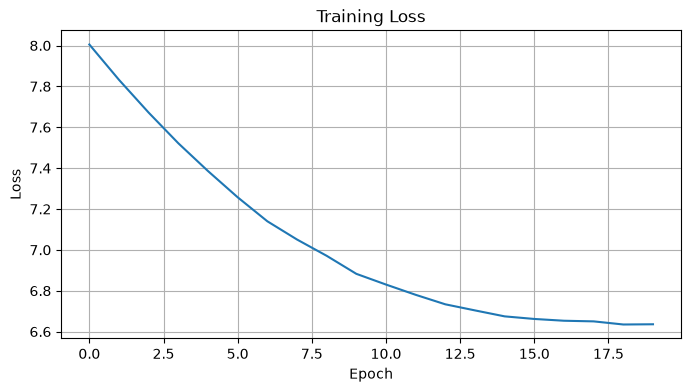

In [23]:
plt.figure(figsize=(8,4))

plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

In [24]:
print(f"\nBest HR@10   : {best_hr:.4f}")
print(f"Best NDCG@10 : {best_ndcg:.4f}")


Best HR@10   : 0.2831
Best NDCG@10 : 0.1702


In [25]:
model.load_state_dict(
    torch.load(
        "cl4srec_best.pth",
        map_location=device
    )
)

hr, ndcg = evaluate(
    model,
    test_loader,
    k=10
)

print(f"\nFinal Evaluation")
print(f"HitRate@10 : {hr:.4f}")
print(f"NDCG@10    : {ndcg:.4f}")


Final Evaluation
HitRate@10 : 0.2831
NDCG@10    : 0.1702
